# 04 - Continual Learning Experiment

## 1. Notebook Goal
Measure how RAC performance changes as the retrieval database grows through staged data accumulation.

## 2. Experimental Design
- Define database-size checkpoints (percent of full memory).
- Rebuild/evaluate retrieval behavior at each checkpoint.
- Keep the test set fixed so only memory size changes.
- Track trend metrics including macro F1 and class-wise behavior.
- Save staged outputs and plot the learning trajectory.

## 3. Inputs
- dataset/CVPR_2024_dataset_Test/
- dataset_text/test.csv
- chroma_db/ source memory used for staged subsets

## 4. Outputs
- results/phase2/continual_learning_results.json
- results/phase2/continual_learning_curve.csv (if enabled)
- figures/phase2/continual_learning_curve.png

## 5. Execution Guide
Run all cells top-to-bottom for a complete staged run; rerun the evaluation cell after changing checkpoint settings.

### Cell 2 - Imports, Config, and Experiment Parameters
Purpose: initialize project dependencies, define continual-learning checkpoints, and configure runtime/output paths for staged evaluation.

In [1]:
import math
import shutil
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("../..").resolve()))

from src.phase2.config import get_phase2_config
from src.phase2.data_utils import build_records_from_csv
from src.phase2.db_client import (
    get_image_collection,
    get_persistent_client,
    get_text_collection,
)
from src.phase2.evaluation import (
    evaluate_variant,
    save_continual_summary_csv,
    save_results,
)
from src.phase2.gpu_utils import get_device, print_device_info, print_gpu_memory
from src.phase2.scoring import global_dnds, idw, kde_dnds, local_dnds, majority_vote
from src.phase2.visualization import plot_continual_learning_curve

CONFIG = get_phase2_config({"continual_db_path": "./chroma_db_continual"})

# Per-notebook GPU controls
PREFER_GPU = True
CLEANUP_INTERVAL = 0
MEMORY_LOG_INTERVAL = 0

# Continual parallel controls
PARALLEL_CONTINUAL_VARIANTS = True
CONTINUAL_MAX_WORKERS = 10
SHOW_NOTEBOOK_PROGRESS = False
CONTINUAL_LOG_INTERVAL = 250

DEVICE = get_device(prefer_gpu=PREFER_GPU)
print_device_info(DEVICE)
if MEMORY_LOG_INTERVAL > 0:
    print_gpu_memory(prefix="Startup GPU memory", device=DEVICE)

REPO_ROOT = Path("../..").resolve()
TRAIN_DIR = REPO_ROOT / "dataset" / "CVPR_2024_dataset_Train"
TEST_DIR = REPO_ROOT / "dataset" / "CVPR_2024_dataset_Test"
TRAIN_CSV = REPO_ROOT / "dataset_text" / "train.csv"
TEST_CSV = REPO_ROOT / "dataset_text" / "test.csv"
RESULTS_PATH = REPO_ROOT / "results" / "phase2" / "continual_learning_results.json"
CONTINUAL_CSV_PATH = REPO_ROOT / "results" / "phase2" / "continual_learning_curve.csv"
CONTINUAL_LOG_PATH = REPO_ROOT / "results" / "phase2" / "continual_learning.log"
FIG_PATH = REPO_ROOT / "figures" / "phase2" / "continual_learning_curve.png"

CONTINUAL_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
CONTINUAL_LOG_PATH.write_text("", encoding="utf-8")
print(f"Continual progress log: {CONTINUAL_LOG_PATH}")

for required in [TRAIN_DIR, TEST_DIR, TRAIN_CSV, TEST_CSV]:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing required input for continual learning notebook: {required}"
        )

train_records, train_missing_examples, train_total_rows = build_records_from_csv(
    csv_path=TRAIN_CSV,
    split_dir=TRAIN_DIR,
    text_column="text",
    label_column="label",
    text_key="text",
)
test_samples, test_missing_examples, test_total_rows = build_records_from_csv(
    csv_path=TEST_CSV,
    split_dir=TEST_DIR,
    text_column="text",
    label_column="label",
    text_key="text",
)

if train_missing_examples:
    print("Skipped train rows with missing image files (up to 10 shown):")
    for item in train_missing_examples:
        print(f"  - {item}")

if test_missing_examples:
    print("Skipped test rows with missing image files (up to 10 shown):")
    for item in test_missing_examples:
        print(f"  - {item}")

if not train_records:
    raise RuntimeError("No train records found for continual-learning simulation.")
if not test_samples:
    raise RuntimeError("No test records found for continual-learning evaluation.")

print(f"Train records used: {len(train_records)} / {train_total_rows}")
print(f"Test samples used: {len(test_samples)} / {test_total_rows}")

variant_fns = {
    "majority_vote": majority_vote,
    "idw": idw,
    "global_dnds": global_dnds,
    "local_dnds": local_dnds,
    "kde_dnds": kde_dnds,
}

d:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU (4.00 GB VRAM, allocated 0.00 GB, reserved 0.00 GB)
Continual progress log: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\continual_learning.log
Train records used: 11685 / 11685
Test samples used: 3452 / 3452


### Cell 3 - Build Evaluation Data and Initialize Clients
Purpose: load test samples, connect to retrieval storage, and prepare the components needed to evaluate performance at each database-size checkpoint.

In [2]:
continual_db_dir = REPO_ROOT / "chroma_db_continual"
if continual_db_dir.exists():
    shutil.rmtree(continual_db_dir)

try:
    client = get_persistent_client(str(continual_db_dir))
    image_collection = get_image_collection(client)
    text_collection = get_text_collection(client)
except Exception as exc:
    raise RuntimeError(f"Failed to initialize isolated continual DB: {exc}") from exc


def _log_progress(message: str) -> None:
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with CONTINUAL_LOG_PATH.open("a", encoding="utf-8") as handle:
        handle.write(f"[{timestamp}] {message}\n")


def add_records_to_db(records: list[dict], start_index: int) -> None:
    batch_size = CONFIG["batch_size"]
    for start in range(0, len(records), batch_size):
        batch = records[start : start + batch_size]
        ids_img, ids_txt, images, docs, metadatas = [], [], [], [], []

        for offset, record in enumerate(batch):
            global_idx = start_index + start + offset
            image_np = np.array(
                Image.open(record["image_path"]).convert("RGB"), dtype=np.uint8
            )
            ids_img.append(f"img_{global_idx}")
            ids_txt.append(f"txt_{global_idx}")
            images.append(image_np)
            docs.append(record["text"])
            metadatas.append({"label": record["label"], "filename": record["text"]})

        try:
            image_collection.add(ids=ids_img, images=images, metadatas=metadatas)
            text_collection.add(ids=ids_txt, documents=docs, metadatas=metadatas)
        except Exception as exc:
            raise RuntimeError(
                f"Failed adding records to continual DB at start={start_index + start}: {exc}"
            ) from exc


def _evaluate_variant_for_step(variant_name: str, score_fn, pct: int):
    _log_progress(f"START variant={variant_name} at db_size={pct}%")
    metrics = evaluate_variant(
        score_fn,
        test_samples,
        image_collection,
        text_collection,
        CONFIG,
        cleanup_interval=CLEANUP_INTERVAL,
        memory_log_interval=MEMORY_LOG_INTERVAL,
        show_progress=SHOW_NOTEBOOK_PROGRESS,
        run_label=f"continual::{variant_name}::{pct}%",
        progress_log_path=str(CONTINUAL_LOG_PATH),
        progress_log_interval=CONTINUAL_LOG_INTERVAL,
    )
    _log_progress(
        f"DONE variant={variant_name} at db_size={pct}% macro_f1={metrics.get('macro_f1', 0.0):.4f}"
    )
    return variant_name, metrics


results = {
    "db_size_percent": [],
    "variants": {name: {"macro_f1": [], "steps": {}} for name in variant_fns},
}

added_count = 0
total_train = len(train_records)
for pct in tqdm(range(10, 101, 10), desc="Continual growth steps"):
    _log_progress(f"START db_size step {pct}%")
    target_count = math.ceil(total_train * (pct / 100.0))
    target_count = min(target_count, total_train)

    if target_count > added_count:
        new_slice = train_records[added_count:target_count]
        add_records_to_db(new_slice, start_index=added_count)
        added_count = target_count

    image_count = image_collection.count()
    text_count = text_collection.count()
    if image_count != added_count or text_count != added_count:
        raise AssertionError(
            f"Collection counts mismatch at {pct}%: image={image_count}, text={text_count}, expected={added_count}"
        )

    results["db_size_percent"].append(pct)

    if PARALLEL_CONTINUAL_VARIANTS:
        workers = max(1, min(CONTINUAL_MAX_WORKERS, len(variant_fns)))
        _log_progress(
            f"Evaluating variants in parallel with {workers} workers at {pct}%"
        )
        with ThreadPoolExecutor(max_workers=workers) as pool:
            futures = {
                pool.submit(
                    _evaluate_variant_for_step, variant_name, score_fn, pct
                ): variant_name
                for variant_name, score_fn in variant_fns.items()
            }
            for future in as_completed(futures):
                variant_name, metrics = future.result()
                results["variants"][variant_name]["macro_f1"].append(
                    metrics["macro_f1"]
                )
                results["variants"][variant_name]["steps"][str(pct)] = {
                    "db_count": added_count,
                    "accuracy": metrics["accuracy"],
                    "macro_f1": metrics["macro_f1"],
                    "weighted_f1": metrics["weighted_f1"],
                    "inference_time_ms": metrics.get("inference_time_ms", 0.0),
                }
    else:
        for variant_name, score_fn in variant_fns.items():
            _, metrics = _evaluate_variant_for_step(variant_name, score_fn, pct)
            results["variants"][variant_name]["macro_f1"].append(metrics["macro_f1"])
            results["variants"][variant_name]["steps"][str(pct)] = {
                "db_count": added_count,
                "accuracy": metrics["accuracy"],
                "macro_f1": metrics["macro_f1"],
                "weighted_f1": metrics["weighted_f1"],
                "inference_time_ms": metrics.get("inference_time_ms", 0.0),
            }

    _log_progress(f"DONE db_size step {pct}%")

if image_collection.count() != total_train or text_collection.count() != total_train:
    raise AssertionError(
        f"Final 100% step must contain the complete training set. "
        f"image={image_collection.count()}, text={text_collection.count()}, expected={total_train}"
    )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1077.45it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Continual growth steps: 100%|██████████| 10/10 [10:11:57<00:00, 3671.72s/it]


### Cell 4 - Run Staged Continual Evaluation
Purpose: iterate over database-size percentages, evaluate selected variant(s) at each stage, and accumulate trend metrics for continual-learning analysis.

Continual learning experiment complete.
Saved JSON results: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\continual_learning_results.json
Saved CSV curve: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\continual_learning_curve.csv
Saved figure: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\figures\phase2\continual_learning_curve.png

CONTINUAL LEARNING SUMMARY TABLE


,db_size_percent,variant,db_count,accuracy,macro_f1,weighted_f1,inference_time_ms
0,10,global_dnds,1169,0.7761,0.7679,0.7730,315.367
1,10,idw,1169,0.7541,0.7383,0.7445,268.587
2,10,kde_dnds,1169,0.7827,0.7752,0.7800,451.082
3,10,local_dnds,1169,0.6428,0.6398,0.6428,291.133
4,10,majority_vote,1169,0.7500,0.7347,0.7406,282.768
5,20,global_dnds,2337,0.8050,0.7996,0.8036,320.516
6,20,idw,2337,0.7767,0.7680,0.7717,266.043
7,20,kde_dnds,2337,0.8097,0.8044,0.8085,467.756
8,20,local_dnds,2337,0.6527,0.6507,0.6522,259.410
9,20,majority_vote,2337,0.7738,0.7662,0.7693,254.533


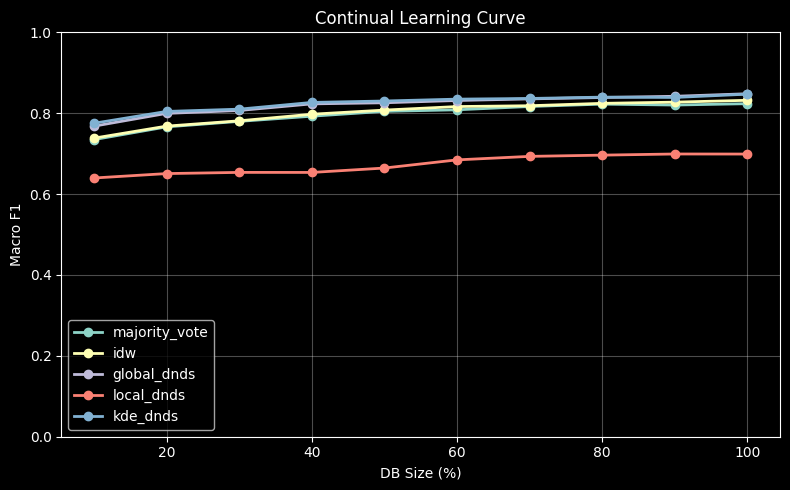

In [3]:
import pandas as pd

save_results(results, str(RESULTS_PATH))
save_continual_summary_csv(results, str(CONTINUAL_CSV_PATH))
plot_continual_learning_curve(results, str(FIG_PATH))

rows = []
for pct in results.get("db_size_percent", []):
    step_key = str(pct)
    for variant_name, payload in results.get("variants", {}).items():
        step_metrics = payload.get("steps", {}).get(step_key, {})
        rows.append(
            {
                "db_size_percent": pct,
                "variant": variant_name,
                "db_count": int(step_metrics.get("db_count", 0)),
                "accuracy": round(float(step_metrics.get("accuracy", 0.0)), 4),
                "macro_f1": round(float(step_metrics.get("macro_f1", 0.0)), 4),
                "weighted_f1": round(float(step_metrics.get("weighted_f1", 0.0)), 4),
                "inference_time_ms": round(float(step_metrics.get("inference_time_ms", 0.0)), 3),
            }
        )

summary_df = pd.DataFrame(rows).sort_values(["db_size_percent", "variant"]).reset_index(drop=True)

print("Continual learning experiment complete.")
print(f"Saved JSON results: {RESULTS_PATH}")
print(f"Saved CSV curve: {CONTINUAL_CSV_PATH}")
print(f"Saved figure: {FIG_PATH}")

print("\n" + "=" * 90)
print("CONTINUAL LEARNING SUMMARY TABLE")
print("=" * 90)
summary_df

### Cell 5 - Save Continual Results and Plot Learning Curve
Purpose: persist staged metrics and generate visualizations that show performance trajectories as retrieval memory increases.

### Cell 6 - Optional Scratch/Follow-Up Analysis
Purpose: reserved for additional diagnostics, alternative plots, or quick checks after the main continual-learning results are produced.